# Resumen de ThinkDSP (Capítulos 1 a 4)
### Señales, ondas, espectros y ruido — explicado en español

Este notebook resume los conceptos y ejercicios clave de los primeros cuatro capítulos del libro **Think DSP** de Allen Downey, a partir de los notebooks originales (`chap01.ipynb` a `chap04.ipynb`).

Para cada tema se explica:
- **Qué es** la señal o el concepto.
- **Qué representa físicamente** (qué fenómeno del mundo real modela).
- El **código clave** usado en el notebook original (a modo de referencia, no es necesario ejecutarlo aquí si no tienes instalado el módulo `thinkdsp`).

> Nota: para ejecutar el código de verdad necesitas el módulo `thinkdsp.py` (parte del repositorio [ThinkDSP de Allen Downey](https://github.com/AllenDowney/ThinkDSP)) y las librerías `numpy`, `matplotlib` e `ipywidgets`.


In [7]:
# Descarga y configuración típica usada en los notebooks originales
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Descargado', local)

import numpy as np
import matplotlib.pyplot as plt


In [8]:
pip install think-dsp

Note: you may need to restart the kernel to use updated packages.


---
## Capítulo 1 — Sonidos y señales (*Sounds and Signals*)

Este capítulo introduce los dos objetos centrales de ThinkDSP:

- **`Signal`**: una función matemática definida para *todos* los valores de tiempo (continua, abstracta). Ejemplos: `CosSignal`, `SinSignal`.
- **`Wave`**: lo que se obtiene al **evaluar** (muestrear) una señal en una secuencia de instantes de tiempo igualmente espaciados. Es lo que realmente se puede "escuchar" o guardar en un archivo `.wav`.

La idea clave es: *una señal es continua e infinita; una onda (wave) es una versión discreta y finita de esa señal, tomada a una determinada frecuencia de muestreo (`framerate`).*


### 1.1 Señales seno y coseno

`CosSignal(freq=440, amp=1.0, offset=0)` representa una **onda coseno pura** de 440 Hz (la nota La4, "A440", el diapasón estándar de afinación). `amp` es la amplitud (volumen) y `offset` es el desfase de fase inicial.

`SinSignal(freq=880, amp=0.5, offset=0)` es una **onda seno pura** al doble de frecuencia (880 Hz, una octava más aguda) y con la mitad de amplitud.

**¿Qué representa físicamente?** Un tono puro, sin armónicos: es el sonido más "simple" posible, como un diapasón o un generador de tonos de laboratorio.


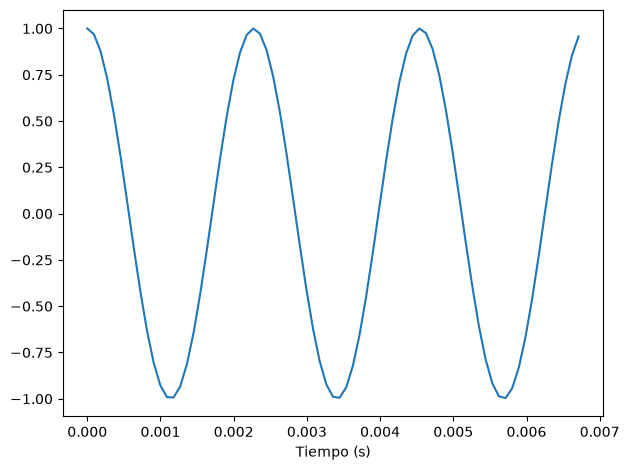

In [9]:
from thinkdsp import CosSignal, SinSignal
from thinkdsp import decorate

cos_sig = CosSignal(freq=440, amp=1.0, offset=0)
sin_sig = SinSignal(freq=880, amp=0.5, offset=0)

cos_sig.plot()
decorate(xlabel='Tiempo (s)')


### 1.2 Suma de señales (`SumSignal`)

Al sumar dos señales (`mix = sin_sig + cos_sig`) se obtiene una nueva señal compuesta. Esto **representa la superposición de tonos**, como cuando suenan dos instrumentos o dos notas al mismo tiempo: el resultado ya no es una onda pura sino una forma de onda más compleja, aunque sigue siendo periódica si las frecuencias son conmensurables.


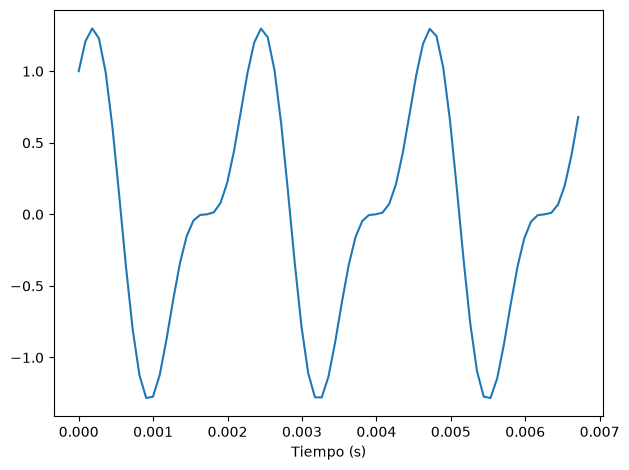

In [10]:
mix = sin_sig + cos_sig
mix.plot()
decorate(xlabel='Tiempo (s)')


### 1.3 De Signal a Wave: muestreo

```python
wave = mix.make_wave(duration=0.5, start=0, framerate=11025)
```

Esto **muestrea** la señal continua `mix` durante 0.5 segundos, tomando 11025 muestras por segundo. El resultado, `wave`, es un arreglo de números (NumPy) que representa la amplitud de la señal en instantes discretos.

- `framerate` = cuántas muestras por segundo (Hz). Es análogo a la tasa de muestreo de un archivo de audio digital (por ejemplo, 44100 Hz en un CD).
- El **paso temporal** entre muestras es `1/framerate` segundos.

Esta es la base de todo el procesamiento digital de señales: **pasar de lo continuo (matemático) a lo discreto (computable)**.


In [11]:
wave = mix.make_wave(duration=0.5, start=0, framerate=11025)
print('Número de muestras:', len(wave.ys))
print('Paso temporal (ms):', 1 / wave.framerate * 1000)


Número de muestras: 5512
Paso temporal (ms): 0.09070294784580499


### 1.4 Reproducir y manipular la onda

- `wave.make_audio()` crea un widget de audio reproducible en el notebook.
- `wave.segment(start, duration)` extrae un **fragmento** de la onda (por ejemplo, 3 periodos).
- `wave.normalize()` escala la onda para que su rango quede entre -1 y 1 (evita distorsión/clipping al reproducir).
- `wave.apodize()` **atenúa el principio y el final** de la onda con una ventana suave, para evitar el "click" o "pop" que se escucha cuando una onda empieza o termina abruptamente (una discontinuidad brusca en amplitud).
- `wave.write('archivo.wav')` guarda la onda como archivo `.wav` real.

**Ejercicio clave:** trabajar con una grabación real (`92002__jcveliz__violin-origional.wav`, un violín) en vez de una señal sintética. Se extrae un segmento donde el tono es más o menos constante, y se observa que, aunque no se distingue la forma de onda exacta a simple vista, sí se ve la **envolvente** (variación lenta de la amplitud general).


In [12]:
from thinkdsp import read_wave

filename = '92002__jcveliz__violin-origional.wav'
wave = read_wave(filename)
wave.make_audio()


FileNotFoundError: [Errno 2] No such file or directory: '92002__jcveliz__violin-origional.wav'

### 1.5 Espectros y filtrado pasa-bajos

`wave.make_spectrum()` calcula el **espectro** de la onda: descompone la señal en las frecuencias (senoides) que la componen, usando la Transformada de Fourier. El espectro muestra **cuánta energía hay en cada frecuencia**.

- `spectrum.plot()` grafica amplitud vs. frecuencia.
- `spectrum.low_pass(3000)` aplica un **filtro pasa-bajos**: elimina (atenúa) las componentes de frecuencia por encima de 3000 Hz.
- Al reconstruir la onda filtrada con `spectrum.make_wave()`, se obtiene una versión "más pura" del sonido, con menos brillo/zumbido en las frecuencias altas.

**¿Qué representa esto?** Es el ejercicio central del capítulo: mostrar que un sonido real (como un violín) es una mezcla rica de frecuencias, y que se puede manipular esa mezcla (filtrar) para cambiar el timbre del sonido, sin cambiar su tono fundamental (la nota que se percibe).


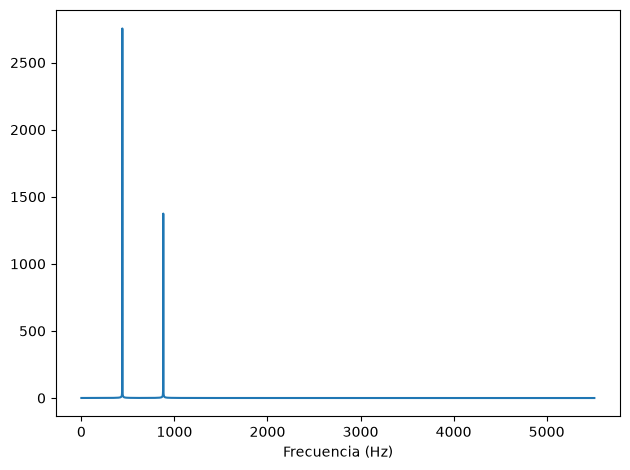

In [13]:
spectrum = wave.make_spectrum()
spectrum.plot(high=10000)
decorate(xlabel='Frecuencia (Hz)')

spectrum.low_pass(3000)
filtered = spectrum.make_wave()
filtered.normalize()
filtered.apodize()


### 1.6 Interacción con sliders

Al final del capítulo se usa `ipywidgets.interact` para crear controles deslizantes (sliders) que permiten elegir en vivo el inicio, duración y frecuencia de corte del filtro, y así **explorar de forma interactiva** cómo cambia el sonido al variar estos parámetros.


---
## Capítulo 2 — Armónicos (*Harmonics*)

Este capítulo estudia señales periódicas **no senoidales** (triangular, cuadrada, diente de sierra) y muestra que, a diferencia del seno/coseno puro, están compuestas por múltiples **armónicos** (múltiplos enteros de una frecuencia fundamental).


### 2.1 Onda triangular (`TriangleSignal`)

Representa una onda cuya forma sube y baja de manera lineal (como un diente en zigzag simétrico). Su espectro muestra la fundamental más armónicos **impares** cuya amplitud decae rápidamente (proporcional a $1/n^2$). Suena más suave/"redondeada" que la cuadrada.

### 2.2 Onda cuadrada (`SquareSignal`)

Alterna abruptamente entre dos niveles (+A y -A). Contiene la fundamental más armónicos **impares** que decaen más lentamente ($1/n$), lo que le da un timbre más "áspero"/brillante, típico de sintetizadores clásicos y de ciertos instrumentos electrónicos.

### 2.3 Onda diente de sierra (`SawtoothSignal`)

Sube linealmente y luego cae abruptamente (o viceversa). Contiene **todos** los armónicos (pares e impares), con amplitud decayendo como $1/n$. Es la más "rica" en armónicos de las tres, y suena muy brillante/zumbante.

**Idea clave común:** cuanto más abrupta o angulosa es la forma de onda en el tiempo, más energía tiene en frecuencias altas (más armónicos significativos).


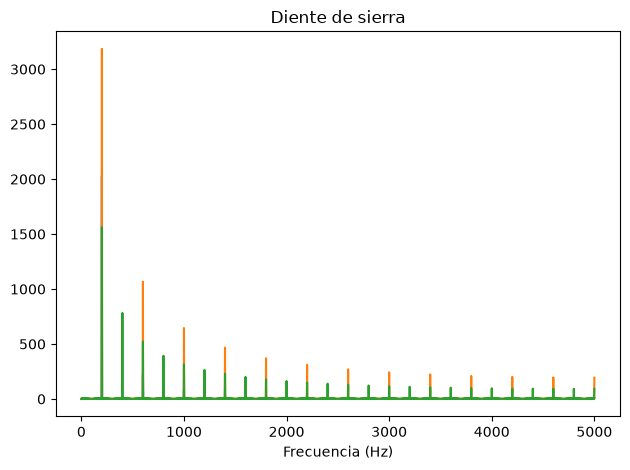

In [14]:
from thinkdsp import TriangleSignal, SquareSignal, SawtoothSignal

for Signal, nombre in [(TriangleSignal, 'Triangular'),
                        (SquareSignal, 'Cuadrada'),
                        (SawtoothSignal, 'Diente de sierra')]:
    signal = Signal(200)
    wave = signal.make_wave(duration=0.5, framerate=10000)
    spectrum = wave.make_spectrum()
    spectrum.plot()
    decorate(xlabel='Frecuencia (Hz)', title=nombre)


### 2.4 Aliasing (submuestreo / solapamiento espectral)

**Ejercicio clave:** se genera un coseno de 4500 Hz y otro de 5500 Hz, ambos muestreados a 10000 Hz (framerate). La **frecuencia de plegado** (Nyquist) es la mitad del framerate: 5000 Hz.

Resultado sorprendente: las ondas de 4500 Hz y 5500 Hz muestreadas a 10 kHz se ven **exactamente iguales**. Esto ocurre porque 5500 Hz está "reflejada" respecto a la frecuencia de Nyquist: $5000 - (5500-5000) = 4500$ Hz.

**¿Qué representa?** El fenómeno de **aliasing**: si una señal contiene frecuencias por encima de la mitad del framerate, esas frecuencias "se disfrazan" de frecuencias más bajas al muestrear, produciendo una representación digital incorrecta/ambigua de la señal original. Es la razón por la que existe el teorema de muestreo de Nyquist-Shannon (hay que muestrear al menos al doble de la frecuencia máxima presente en la señal).

También se muestra cómo, en una señal triangular de 1100 Hz, los armónicos superiores a la frecuencia de Nyquist se "pliegan" (aparecen reflejados) dentro del espectro visible.


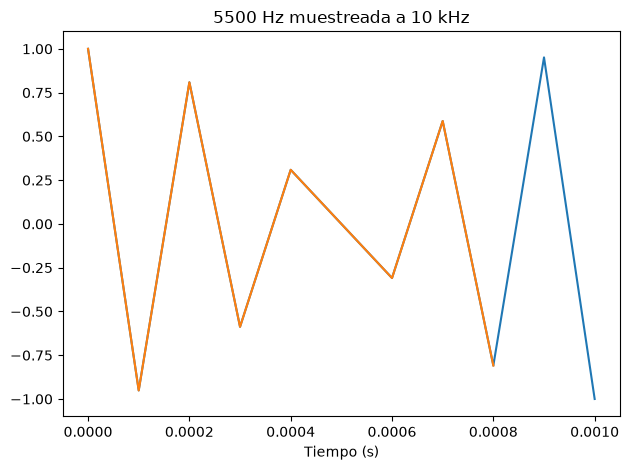

In [15]:
from thinkdsp import CosSignal

# 4500 Hz y 5500 Hz muestreadas a 10 kHz se ven idénticas: aliasing
for freq in [4500, 5500]:
    signal = CosSignal(freq)
    duration = signal.period * 5
    segment = signal.make_wave(duration, framerate=10000)
    segment.plot()
    decorate(xlabel='Tiempo (s)', title=f'{freq} Hz muestreada a 10 kHz')


### 2.5 Amplitud y fase (FFT)

Se usa `np.fft.rfft` (FFT real, optimizada para señales reales) para descomponer una onda diente de sierra en sus componentes de frecuencia (`hs`), y `np.fft.rfftfreq` para obtener las frecuencias correspondientes.

- **Magnitud** (`np.absolute(hs)`): cuánta energía hay en cada frecuencia (esto es lo que normalmente vemos en un espectro).
- **Fase** (`np.angle(hs)`): el desfase de cada componente senoidal respecto al origen de tiempo.

**Ejercicio clave — ¿qué representa la fase?** Se **desordena aleatoriamente** el vector de fases (`random.shuffle(angle)`) manteniendo las mismas magnitudes, y se reconstruye la onda. El resultado:
- La **forma de onda en el tiempo cambia drásticamente** (se ve muy distinta).
- Pero al **escucharla**, suena prácticamente **igual** que la original.

**Conclusión conceptual:** el oído humano es en gran medida "sordo" a la fase; percibimos un sonido principalmente por qué frecuencias contiene y con qué magnitud (esto es la base de por qué el espectro de magnitud, y no el de fase, es lo que solemos analizar y lo que codecs de audio con pérdida explotan).


In [16]:
import numpy as np

hs = np.fft.rfft(wave.ys)
n = len(wave.ys)
fs = np.fft.rfftfreq(n, d=1/wave.framerate)

magnitude = np.absolute(hs)
angle = np.angle(hs)

import random
random.shuffle(angle)  # desordenamos las fases, dejamos igual la magnitud

i = complex(0, 1)
spectrum = wave.make_spectrum()
spectrum.hs = magnitude * np.exp(i * angle)
wave2 = spectrum.make_wave()   # onda con forma distinta...
wave2.make_audio()             # ...pero que suena casi igual


---
## Capítulo 3 — Señales no periódicas (*Non-periodic signals*)

Hasta ahora todas las señales eran periódicas (se repiten exactamente). Este capítulo estudia señales cuya frecuencia **cambia con el tiempo**, y las herramientas para analizarlas.


### 3.1 Chirp (barrido de frecuencia)

`Chirp(start=220, end=880)` genera una señal cuya frecuencia **aumenta linealmente** desde 220 Hz (nota La3) hasta 880 Hz (La5) a lo largo de la duración. `ExpoChirp` hace lo mismo pero con un **barrido exponencial** (la frecuencia crece más lento al principio y más rápido al final, o viceversa según implementación).

**¿Qué representa?** El sonido de una sirena, un "glissando", o el barrido de frecuencias usado para probar la respuesta de un altavoz o una sala. Al comparar el segmento cerca del inicio (baja frecuencia, oscilación lenta) con el segmento cerca del final (alta frecuencia, oscilación rápida) se ve claramente el cambio de frecuencia en el dominio del tiempo.

Este es el ejemplo perfecto de una señal donde **ya no tiene sentido hablar de "la" frecuencia** de la señal completa: la frecuencia es una función del tiempo.


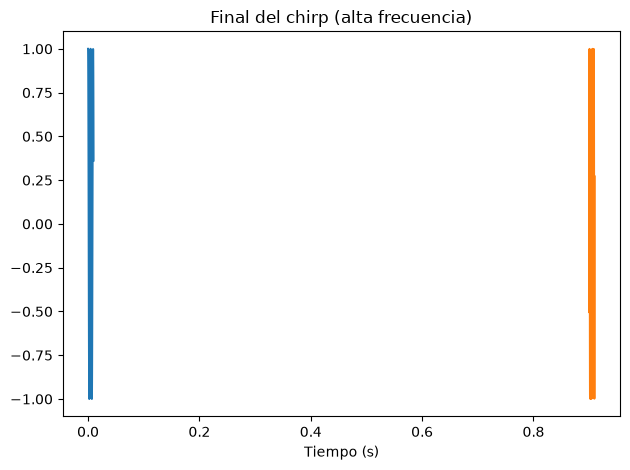

In [17]:
from thinkdsp import Chirp, ExpoChirp

signal = Chirp(start=220, end=880)
wave1 = signal.make_wave(duration=2)

wave1.segment(start=0, duration=0.01).plot()
decorate(xlabel='Tiempo (s)', title='Inicio del chirp (baja frecuencia)')

wave1.segment(start=0.9, duration=0.01).plot()
decorate(xlabel='Tiempo (s)', title='Final del chirp (alta frecuencia)')


### 3.2 Leakage (fuga espectral)

**Ejercicio clave:** se toma una `SinSignal(freq=440)` pura y se generan dos ondas:

1. Con una duración **múltiplo exacto** del periodo (`period * 30`): el espectro resultante muestra un único pico muy limpio en 440 Hz.
2. Con una duración que **no** es múltiplo exacto del periodo (`period * 30.25`): el espectro muestra energía "esparcida" alrededor de 440 Hz en vez de un pico limpio.

**¿Qué representa este fenómeno (leakage)?** La Transformada de Fourier Discreta asume implícitamente que el segmento analizado se repite indefinidamente (es periódico). Si el corte del segmento no coincide con un número entero de periodos, se produce una **discontinuidad artificial** en el punto donde "se pega" el final con el principio, y esa discontinuidad introduce energía espuria en frecuencias vecinas: eso es la fuga o "leakage".

**Solución — ventaneo (`wave.hamming()`):** aplicar una función de ventana (como la de Hamming) que atenúa suavemente los extremos del segmento antes de calcular el espectro, reduciendo la discontinuidad y por tanto el leakage (a costa de reducir un poco la energía total y la resolución).


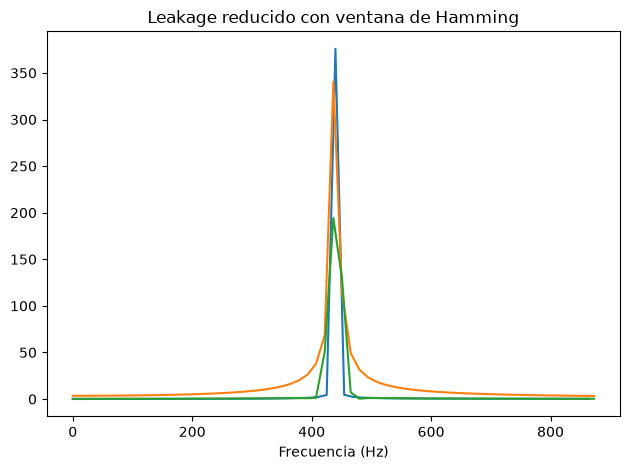

In [18]:
from thinkdsp import SinSignal

signal = SinSignal(freq=440)

# Caso 1: duración múltiplo exacto del período -> espectro limpio
wave_ok = signal.make_wave(duration=signal.period * 30)
wave_ok.make_spectrum().plot(high=880)
decorate(xlabel='Frecuencia (Hz)', title='Sin leakage')

# Caso 2: duración NO múltiplo del período -> leakage
wave_leak = signal.make_wave(duration=signal.period * 30.25)
wave_leak.make_spectrum().plot(high=880)
decorate(xlabel='Frecuencia (Hz)', title='Con leakage')

# Solución: ventana de Hamming
wave_leak.hamming()
wave_leak.make_spectrum().plot(high=880)
decorate(xlabel='Frecuencia (Hz)', title='Leakage reducido con ventana de Hamming')


### 3.3 Espectrograma

Si a una señal **no periódica** cuya frecuencia cambia (como un chirp) se le calcula un único espectro sobre toda su duración, el resultado es una especie de "borrón de movimiento": se ven todas las frecuencias que aparecieron en algún momento, pero **se pierde la información de cuándo** ocurrió cada una.

**Solución — el espectrograma:** dividir la onda en **segmentos cortos** (ventanas de tiempo) y calcular el espectro de cada segmento por separado. El resultado es una imagen 2D: eje X = tiempo, eje Y = frecuencia, y el color/intensidad = magnitud. Esto sí muestra **cómo cambia el espectro a lo largo del tiempo**.

**Compromiso tiempo–frecuencia (ejercicio clave):**
- Segmentos **largos** → mejor **resolución en frecuencia**, pero peor resolución temporal (no se sabe bien *cuándo* ocurrió cada frecuencia).
- Segmentos **cortos** → mejor **resolución temporal**, pero peor resolución en frecuencia (las frecuencias se ven "borrosas"/anchas).

Este es un ejemplo concreto del **principio de incertidumbre tiempo-frecuencia**: no se puede tener precisión perfecta en tiempo y en frecuencia simultáneamente.

El notebook original llama en broma "Eye of Sauron" (el ojo de Sauron) al espectro de un chirp, por su forma característica de "V" o "ojo" cuando la frecuencia inicial y final varían.


In [ ]:
def plot_spectrogram(wave, seg_length):
    spectrogram = wave.make_spectrogram(seg_length)
    spectrogram.plot(high=700)
    decorate(xlabel='Tiempo (s)', ylabel='Frecuencia (Hz)')

signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1, framerate=11025)

plot_spectrogram(wave, 512)   # resolución intermedia
plot_spectrogram(wave, 1024)  # mejor resolución en frecuencia, peor en tiempo
plot_spectrogram(wave, 256)   # mejor resolución en tiempo, peor en frecuencia


---
## Capítulo 4 — Ruido (*Noise*)

Este capítulo estudia señales **aleatorias** (ruido) y cómo se caracterizan por la forma de su espectro de potencia, es decir, cómo se distribuye su energía entre las distintas frecuencias.


### 4.1 Ruido uniforme no correlacionado — UU noise (`UncorrelatedUniformNoise`)

Cada muestra es un número aleatorio independiente con distribución **uniforme**. "No correlacionado" significa que el valor de una muestra no depende del valor de las anteriores.

**Espectro de potencia:** al graficar `spectrum.plot_power()` (el cuadrado de la magnitud, más habitual para analizar ruido), se observa que la potencia es, en promedio, **igual en todas las frecuencias**.

**Espectro integrado (`make_integrated_spectrum`):** es la suma acumulada normalizada de la potencia, desde frecuencia 0 hasta cada frecuencia. Si sale una **línea recta**, significa que la potencia se reparte uniformemente entre frecuencias.

**¿Qué representa esto? → Ruido blanco.** Por analogía con la luz blanca (que contiene todos los colores/frecuencias por igual), se llama "ruido blanco" al que tiene energía pareja en todo el espectro. Es el ruido "estático" típico, como el de una radio desintonizada.


In [ ]:
from thinkdsp import UncorrelatedUniformNoise

signal = UncorrelatedUniformNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)

spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frecuencia (Hz)', ylabel='Potencia')

integ = spectrum.make_integrated_spectrum()
integ.plot_power()
decorate(xlabel='Frecuencia (Hz)', ylabel='Potencia acumulada (ruido blanco → línea recta)')


### 4.2 Ruido browniano — Brownian noise (`BrownianNoise`)

También llamado **ruido rojo**. Se genera, conceptualmente, integrando (sumando acumulativamente) ruido no correlacionado — es análogo al **movimiento browniano** de una partícula empujada aleatoriamente (de ahí el nombre).

Al escucharlo suena **más apagado/opaco** que el ruido blanco, porque concentra su energía en frecuencias **bajas**.

**Espectro de potencia en escala log-log:** al graficar potencia vs. frecuencia con ambos ejes en escala logarítmica, se obtiene aproximadamente una **línea recta con pendiente cercana a -2**, lo que indica una relación:

$$ P(f) \approx \frac{K}{f^2} $$

Es decir, la potencia decae con el cuadrado inverso de la frecuencia: mucha energía en graves, casi nada en agudos. `spectrum.estimate_slope()` estima numéricamente esta pendiente (el notebook original obtiene un valor cercano a -1.8, no exactamente -2, por efectos de la implementación discreta).


In [ ]:
from thinkdsp import BrownianNoise

signal = BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)

spectrum = wave.make_spectrum()
result = spectrum.estimate_slope()
print('Pendiente estimada (aprox. -2 para ruido browniano):', result.slope)


### 4.3 Ruido rosa — Pink noise (`PinkNoise`, parámetro β)

El ruido rosa generaliza el concepto anterior con un parámetro $\beta$ que controla cómo decae la potencia con la frecuencia:

$$ P(f) \approx \frac{K}{f^{\beta}} $$

- **β = 0** → potencia constante en todas las frecuencias → **ruido blanco**.
- **β = 1** → $P = K/f$ → **ruido rosa** propiamente dicho (también llamado "ruido 1/f"). Suena más "cálido"/natural; aparece en muchísimos fenómenos naturales (tráfico, cascadas, latidos del corazón, música).
- **β = 2** → $P = K/f^2$ → equivale al **ruido browniano/rojo** del punto anterior.

**Ejercicio clave:** generar los tres casos (β = 0, 1, 2) y comparar sus espectros de potencia en escala log-log: se ven como tres líneas paralelas con distinta pendiente (0, -1 y -2 respectivamente), lo cual ilustra visualmente cómo un solo parámetro β controla el "color" completo del ruido, desde blanco (brillante) hasta rojo (grave/apagado), pasando por rosa (intermedio).


In [ ]:
from thinkdsp import PinkNoise

betas = [0, 1, 2]  # blanco, rosa, browniano/rojo
for beta in betas:
    signal = PinkNoise(beta=beta)
    wave = signal.make_wave(duration=0.5, framerate=1024)
    spectrum = wave.make_spectrum()
    spectrum.plot_power(label=f'beta={beta}')
plt.xscale('log'); plt.yscale('log')
decorate(xlabel='Frecuencia (Hz)', ylabel='Potencia')


### 4.4 Ruido gaussiano no correlacionado — UG noise (`UncorrelatedGaussianNoise`)

Similar al ruido UU, pero cada muestra sigue una **distribución normal (gaussiana)** en vez de uniforme.

**Propiedad notable (ejercicio clave):** el espectro de un ruido UG es, a su vez, **también ruido gaussiano** (tanto la parte real como la imaginaria de cada componente de frecuencia siguen una distribución normal). Esto se comprueba con un **gráfico de probabilidad normal** (`normal_prob_plot`): si los puntos caen aproximadamente sobre una línea recta, la distribución de esos datos es gaussiana.

Esta propiedad es una consecuencia del hecho de que la Transformada de Fourier es una **transformación lineal**, y una combinación lineal de variables gaussianas independientes sigue siendo gaussiana.

**¿Por qué importa?** El ruido gaussiano es el modelo más usado en ingeniería y estadística para representar ruido de fondo (térmico, electrónico, de medición), precisamente porque tiene estas propiedades matemáticas convenientes y porque el Teorema Central del Límite predice que la suma de muchas fuentes de ruido pequeñas e independientes tiende a una distribución gaussiana.


In [ ]:
from thinkdsp import UncorrelatedGaussianNoise

signal = UncorrelatedGaussianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
spectrum = wave.make_spectrum()

# El espectro de ruido gaussiano también es gaussiano:
# se puede verificar con un gráfico de probabilidad normal
# (comparar spectrum.real y spectrum.imag contra una distribución normal teórica)


---
## Tabla resumen: qué representa cada señal

| Señal / concepto | Capítulo | ¿Qué representa? |
|---|---|---|
| `CosSignal`, `SinSignal` | 1 | Tono puro, una sola frecuencia (ej. diapasón) |
| `SumSignal` (mezcla) | 1 | Superposición de varios tonos sonando a la vez |
| `Wave` (muestreo) | 1 | Versión digital/discreta de una señal continua |
| Filtro pasa-bajos (`low_pass`) | 1 | Eliminar frecuencias altas → sonido más "opaco" |
| `TriangleSignal` | 2 | Onda con armónicos impares, decaimiento rápido (suave) |
| `SquareSignal` | 2 | Onda con armónicos impares, decaimiento lento (brillante/áspera) |
| `SawtoothSignal` | 2 | Onda con todos los armónicos (la más "rica" espectralmente) |
| Aliasing | 2 | Frecuencias altas mal muestreadas se confunden con frecuencias bajas |
| Fase de la FFT | 2 | Controla la forma de onda, pero casi no afecta cómo se percibe el sonido |
| `Chirp` / `ExpoChirp` | 3 | Frecuencia que cambia con el tiempo (sirena, glissando) |
| Leakage espectral | 3 | Energía "esparcida" por analizar un segmento no periódico |
| Ventaneo (Hamming) | 3 | Técnica para reducir el leakage |
| Espectrograma | 3 | Cómo cambia el espectro a lo largo del tiempo (compromiso tiempo/frecuencia) |
| `UncorrelatedUniformNoise` | 4 | Ruido blanco: potencia igual en todas las frecuencias |
| `BrownianNoise` | 4 | Ruido rojo/browniano: potencia ∝ 1/f² (grave, "apagado") |
| `PinkNoise(beta)` | 4 | Familia de ruidos de color, β interpola entre blanco, rosa y rojo |
| `UncorrelatedGaussianNoise` | 4 | Ruido con distribución normal; su espectro también es gaussiano |

### Hilo conductor de los cuatro capítulos

1. **Cap. 1** — De la señal matemática continua a la onda digital muestreada; introducción al espectro y al filtrado.
2. **Cap. 2** — Señales periódicas complejas están hechas de armónicos; riesgo de aliasing al muestrear; la fase importa poco para la percepción.
3. **Cap. 3** — Señales cuya frecuencia cambia con el tiempo; problemas de analizar segmentos no periódicos (leakage) y cómo visualizar la evolución temporal del espectro (espectrograma).
4. **Cap. 4** — El ruido también tiene una "forma" espectral característica (blanco, rosa, rojo/browniano, gaussiano), y esa forma se puede cuantificar y comparar.
